## 4. Overfitting Experiment

In the model selection notebook we saw that the CNN reaches nearly 100% on the training set, while the validation set is stuck at around 74,9%. This gap is a clear sign that the model is memorizing the training cards instead of learning patterns. In this notebook I want to apply some regularization techniques and see if we can close this gap.

In this notebook we will try this techniques:
1. **Dropout** — randomly drops neurons during training, so the network cant rely on single features
2. **Batch Normalization** — normalizes the activations between layers, which usually stabilizes training
3. **L2 Regularization** — penalizes large weights in the loss function, which keeps the model from getting too confident on the training data

Each config is run 3 times so we can report mean and std and see if a result is real or just random noise from the initialization.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.dataset import Dataset
from models.cnn_builder import CNNBuilder
from evaluation.evaluation_metrics import EvaluationMetrics
from models.training_callbacks import default_callbacks
from data.rarity_classes import RARITY_CLASSES
from evaluation.multi_run_eval import multi_run_evaluation

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 1750 samples
Validation set: 375 samples
Test set: 375 samples
Input shape: (168, 120, 3)
Number of classes: 5


## 4.1 Experiments

Each config uses the same baseline architecture (32 → 64 conv, 128 dense) and only flips one regularization flag on the CNNBuilder. This way we isolate the effect of each technique. All runs use the default callbacks (early stopping) and 30 epochs.

In [4]:

def make_baseline():
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])
    return b.build_model()
                                        
def make_dropout():       
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])
    b.apply_dropout = True
    return b.build_model()
                           
def make_batchnorm():                   
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])
    b.apply_batch_normalization = True      
    return b.build_model()
                
def make_l2():            
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])
    b.apply_regularization = True       
    return b.build_model()                  
                                    
configs = [               
    ("Baseline",     make_baseline),                   
    ("Dropout",      make_dropout),
    ("BatchNorm",    make_batchnorm),
    ("L2",           make_l2),          
]

histories = {}
summaries = []
for name, factory in configs:           
    print(f"\n=== {name} ===")
    summary, history = multi_run_evaluation(
        factory,
        X_train, y_train, X_val, y_val, X_test, y_test, 
        num_runs=3,
        epochs=30,        
        description=name,       
    )         
    summaries.append(summary)
    histories[name] = history[0]
      
  



=== Baseline ===
  Baseline run 1/3... 

2026-05-03 17:51:58.461230: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-03 17:51:58.461286: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-03 17:51:58.461298: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-03 17:51:58.461313: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-03 17:51:58.461331: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-03 17:52:00.355934: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


acc=0.68, f1=0.681525260268905
  Baseline run 2/3... acc=0.6826666666666666, f1=0.6784278427750019
  Baseline run 3/3... acc=0.7093333333333334, f1=0.7034242615336499

Baseline: acc=69.06666666666666% ± 1.3244146156223424%, f1=0.6877924548591855 ± 0.01112545231181648

=== Dropout ===
  Dropout run 1/3... acc=0.672, f1=0.6741261046643
  Dropout run 2/3... acc=0.64, f1=0.6374956995295978
  Dropout run 3/3... acc=0.688, f1=0.6847042615122045

Dropout: acc=66.66666666666666% ± 1.9955506062794333%, f1=0.6654420219020342 ± 0.020227407993163093

=== BatchNorm ===
  BatchNorm run 1/3... acc=0.22133333333333333, f1=0.10612244897959182
  BatchNorm run 2/3... acc=0.304, f1=0.18762494050452166
  BatchNorm run 3/3... acc=0.23466666666666666, f1=0.12127751093268335

BatchNorm: acc=25.333333333333336% ± 3.623789708558135%, f1=0.1383416334722656 ± 0.03539352332209218

=== L2 ===
  L2 run 1/3... acc=0.7066666666666667, f1=0.7022433726616721
  L2 run 2/3... acc=0.6826666666666666, f1=0.680722599016819
 

In [5]:

                                                                                                                                                                
df = pd.DataFrame([{
    "Config": s["name"],                                                                                                                                       
    "Acc Mean": f"{s['accuracy_mean']*100:.1f}%",
    "Acc Std":  f"{s['accuracy_std']*100:.1f}%",
    "F1 Mean":  f"{s['f1_mean']:.3f}",  
    "F1 Std":   f"{s['f1_std']:.3f}",                                                                                                                          
    "Acc Min":  f"{s['accuracy_min']*100:.1f}%",                                                                                                               
    "Acc Max":  f"{s['accuracy_max']*100:.1f}%",                                                                                                               
} for s in summaries])                                                                                                                                         
                                            
print(df.to_string(index=False))

   Config Acc Mean Acc Std F1 Mean F1 Std Acc Min Acc Max
 Baseline    69.1%    1.3%   0.688  0.011   68.0%   70.9%
  Dropout    66.7%    2.0%   0.665  0.020   64.0%   68.8%
BatchNorm    25.3%    3.6%   0.138  0.035   22.1%   30.4%
       L2    70.0%    1.3%   0.696  0.011   68.3%   71.2%


From the table we can see that the regularization techniques didn't really help us:

- **Baseline** -> 69,1% accuracy / F1 0,688
- **Dropout** -> 66,7% accuracy / F1 0,665 — slightly worse than the baseline
- **BatchNorm** -> 25,3% accuracy / F1 0,138 — completely collapses, basically worse than random guessing
- **L2** -> 70,0% accuracy / F1 0,696 — only a tiny improvement over the baseline, within the std range

So none of the techniques is a real win. L2 is the only one that doesn't hurt, but the improvement is so small that it could just be noise. BatchNorm clearly breaks the training in this setup.

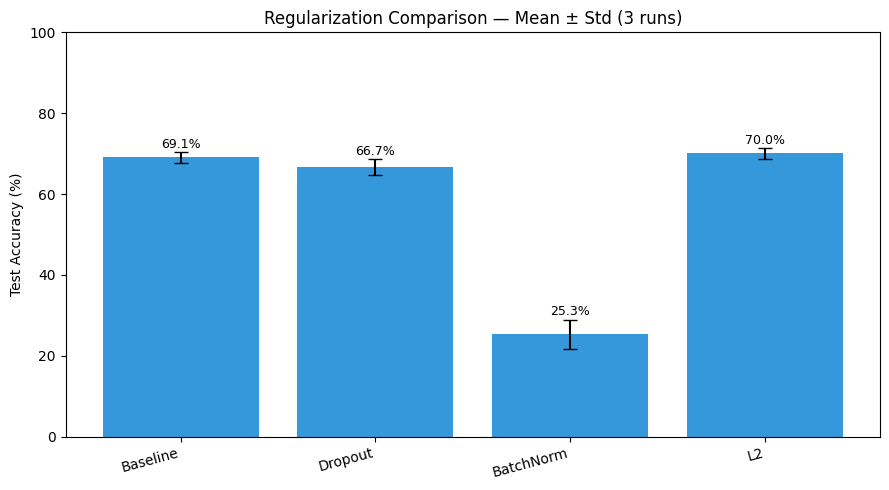

In [6]:
names = [s["name"] for s in summaries]      
means = [s["accuracy_mean"] * 100 for s in summaries]
stds = [s["accuracy_std"] * 100 for s in summaries]
                                                                                                                                                                
x = np.arange(len(names))               
plt.figure(figsize=(9, 5))                                                                                                                                     
plt.bar(x, means, yerr=stds, capsize=5, color="#3498db")                                                                                                       
plt.xticks(x, names, rotation=15, ha="right")
plt.ylabel("Test Accuracy (%)")                                                                                                                                
plt.title("Regularization Comparison — Mean ± Std (3 runs)")
plt.ylim(0, 100)                                                                                                                                               
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(i, m + s + 1, f"{m:.1f}%", ha="center", fontsize=9)                                                                                               
plt.tight_layout()                                                                                                                                             
plt.show()  

## 4.2 Visualize Training vs Validation Loss

The accuracy table only tells us what the model ends up at, not how it got there. To see if the regularization actually closes the overfitting gap, we plot training vs validation loss per config.

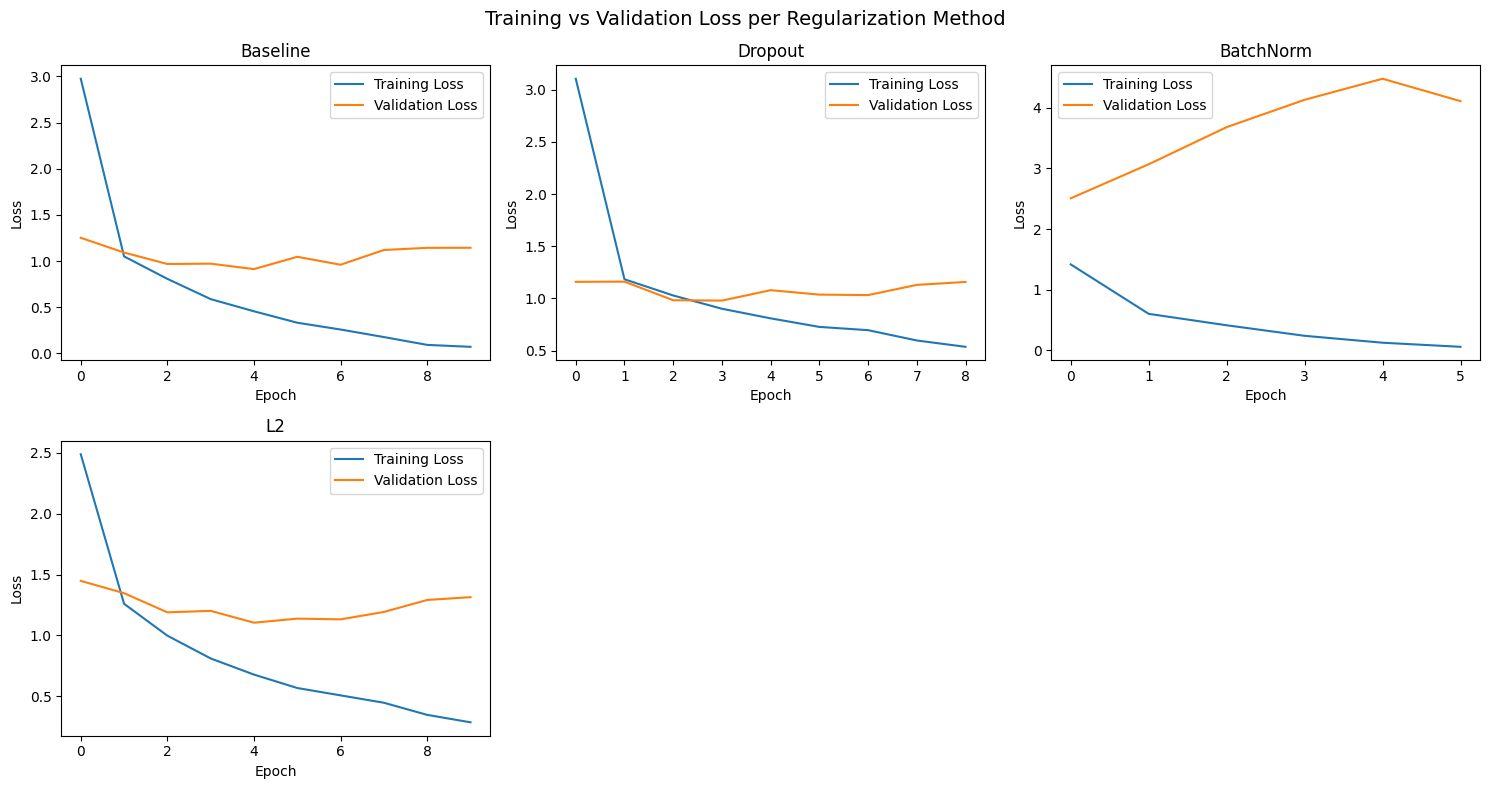

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'], label='Training Loss')
    axes[i].plot(history.history['val_loss'], label='Validation Loss')
    axes[i].set_title(name)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

# Hide the 5th and 6th subplot
axes[4].set_visible(False)
axes[5].set_visible(False)

plt.suptitle('Training vs Validation Loss per Regularization Method', fontsize=14)
plt.tight_layout()
plt.show()

From these plots we can see that the model is still overfitting in every config. The training loss keeps dropping while the validation loss flattens or even goes up.

- **Baseline** -> training loss drops close to 0 while validation loss flattens around 1,1 and starts increasing again
- **Dropout** -> training loss stays higher around 0,5 so the gap to the validation loss is the smallest of all configs, but the validation loss itself is not better than the baseline
- **BatchNorm** -> the validation loss goes up to ~4 while the training loss drops to near 0, the training is completely broken and explains the bad accuracy
- **L2** -> looks very similar to the baseline, training loss drops a bit slower but the validation loss still flattens around 1,2-1,3 and the gap stays big

So none of these techniques alone solve the problem. I assume the issue is more about the dataset size and model capacity than about regularization. I guess the model simply has enough capacity to memorize 1750 training samples.

## 4.3 Validation Accuracy Comparison

Here we plot the validation accuracy of all configs in one graph to see how they progress over the epochs.

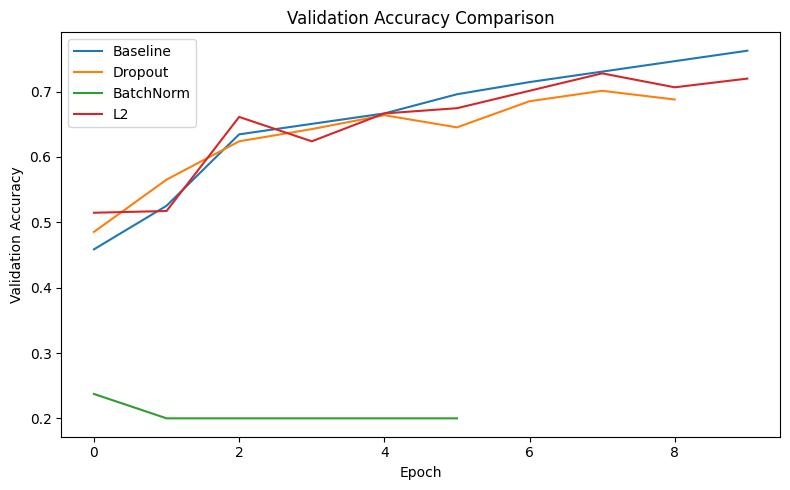

In [8]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Baseline, Dropout and L2 all settle in the same range around 65-70%. BatchNorm stays way below the rest, which matches the loss plot. So in terms of validation accuracy, no technique gives us a real advantage over the baseline.

## 4.4 Evaluation of the best config

We pick the config with the lowest validation loss and evaluate it on the test set. The classification report and the confusion matrix show us how the model performs per rarity class and where it gets confused.

Best configuration by val_loss: Baseline
Accuracy: 0.6693333333333333
F1 Score (Macro): 0.653793592038381
              precision    recall  f1-score   support

      Common       0.64      0.81      0.72        75
    Uncommon       0.48      0.43      0.45        75
        Rare       0.65      0.37      0.47        75
  Ultra Rare       0.80      0.88      0.84        75
 Secret Rare       0.73      0.85      0.79        75

    accuracy                           0.67       375
   macro avg       0.66      0.67      0.65       375
weighted avg       0.66      0.67      0.65       375



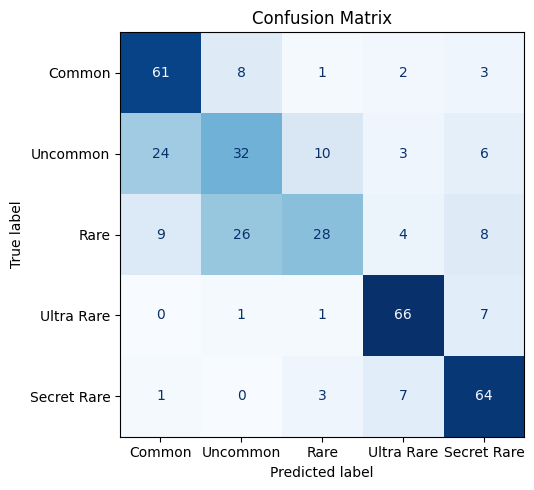

In [22]:
best_name = min(
    histories,
    key=lambda n: min(histories[n].history['val_loss']),
)
print(f"Best configuration by val_loss: {best_name}")

factories = dict(configs)
best_model = factories[best_name]()
best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=default_callbacks(),
    verbose=0,
)

y_pred_test = best_model.predict(X_test, verbose=0)

metrics = EvaluationMetrics(y_test, y_pred_test)
metrics.print_eval_metrics()

metrics.print_classification_report(RARITY_CLASSES)
metrics.plot_confusion_matrix(RARITY_CLASSES)

The best config by validation loss is the baseline itself, so no regularization actually made significant improvements. The retrained baseline ends at 66,9% accuracy and 0,654 F1 on the test set, which is a bit lower than the multi run mean but still in the same range.

Looking at the per class breakdown:

- **Common** -> precision 0,64 / recall 0,81 — high recall, the model catches most Commons (61 out of 75), but the precision is low because it also predicts Common for 24 Uncommons and 9 Rares.
- **Uncommon** -> precision 0,48 / recall 0,43 — the weakest class. 24 Uncommons are predicted as Common and 10 as Rare, so the model can barely tell these three apart.
- **Rare** -> precision 0,65 / recall 0,37 — only 28 out of 75 Rares are caught. 26 are predicted as Uncommon and 9 as Common, the model clearly underpredicts Rare.
- **Ultra Rare** -> precision 0,80 / recall 0,88 — clearly the strongest class. 66 out of 75 are caught correctly
- **Secret Rare** -> precision 0,73 / recall 0,85 — strong as well, 64 out of 75 caught

This confirms what I already assumed in notebook 1. Common, Uncommon and Rare only differ in a tiny symbol on the bottom, so the model mixes them up heavily and the holographic or shiny effects do not appear well on the images. Ultra Rare and Secret Rare both have heavy holographic effects and the general structure is different. They have for example the illustration of the pokemon all over the card, I guess this is what the model can clearly seperate the lower rarities, but mixes them up with each other. So the errors are not random, they happen exactly between the visually similar classes.


## 4.5 Summary

- *Baseline* -> **Accuracy: 69,1% / F1: 0,688** — overfits, validation loss diverges from training loss
- *Dropout* -> **Accuracy: 66,7% / F1: 0,665** — almost no effect on overfitting, slightly worse than baseline
- *BatchNorm* -> **Accuracy: 25,3% / F1: 0,138** — training collapses, unstable validation loss with big spikes
- *L2* -> **Accuracy: 70,0% / F1: 0,696** — slightly higher accuracy than baseline but still overfits, similar gap as baseline

None of the regularization techniques significantly improved the overfitting problem on the current architecture. My assumption is that the dataset is too small relative to the model capacity, so the model still has enough room to memorize. In addition we could witness that it struggles to differentiate between Common, Uncommon and Rare cards. I assume it is because the holographic and shiny effects are not well present in the images. In the next notebook we will tackle this with data augmentation and a smaller architecture (Global Average Pooling instead of Flatten).